# 1. Load dataset

In [18]:
import pandas as pd

df = pd.read_csv('spotify_dataset.csv')
print(df.columns.tolist())

['Artist(s)', 'song', 'text', 'Length', 'emotion', 'Genre', 'Album', 'Release Date', 'Key', 'Tempo', 'Loudness (db)', 'Time signature', 'Explicit', 'Popularity', 'Energy', 'Danceability', 'Positiveness', 'Speechiness', 'Liveness', 'Acousticness', 'Instrumentalness', 'Good for Party', 'Good for Work/Study', 'Good for Relaxation/Meditation', 'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine', 'Similar Artist 1', 'Similar Song 1', 'Similarity Score 1', 'Similar Artist 2', 'Similar Song 2', 'Similarity Score 2', 'Similar Artist 3', 'Similar Song 3', 'Similarity Score 3']


In [19]:
print(f"Kształt zbioru danych (wiersze, kolumny): {df.shape}")

print(df.info())

df.head()

Kształt zbioru danych (wiersze, kolumny): (551443, 39)
<class 'pandas.DataFrame'>
RangeIndex: 551443 entries, 0 to 551442
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Artist(s)                       551443 non-null  str    
 1   song                            551427 non-null  str    
 2   text                            551443 non-null  str    
 3   Length                          551443 non-null  str    
 4   emotion                         551443 non-null  str    
 5   Genre                           551443 non-null  str    
 6   Album                           551391 non-null  str    
 7   Release Date                    551443 non-null  str    
 8   Key                             551443 non-null  str    
 9   Tempo                           551443 non-null  int64  
 10  Loudness (db)                   551443 non-null  str    
 11  Time signature                  55

,Artist(s),song,text,Length,emotion,Genre,Album,Release Date,Key,Tempo,...,Good for Morning Routine,Similar Artist 1,Similar Song 1,Similarity Score 1,Similar Artist 2,Similar Song 2,Similarity Score 2,Similar Artist 3,Similar Song 3,Similarity Score 3
0,!!!,Even When the Waters Cold,Friends told her she was better off at the bot...,03:47,sadness,hip hop,Thr!!!er,29th April 2013,D min,105,...,0,Corey Smith,If I Could Do It Again,0.986061,Toby Keith,Drinks After Work,0.983719,Space,Neighbourhood,0.983236
1,!!!,One Girl / One Boy,"Well I heard it, playing soft From a drunken b...",04:03,sadness,hip hop,Thr!!!er,29th April 2013,A# min,117,...,0,Hiroyuki Sawano,BRE@TH//LESS,0.995409,When In Rome,Heaven Knows,0.990905,Justice Crew,Everybody,0.984483
2,!!!,Pardon My Freedom,"Oh my god, did I just say that out loud? Shoul...",05:51,joy,hip hop,Louden Up Now,8th June 2004,A Maj,121,...,0,Ricky Dillard,More Abundantly Medley Live,0.993176,Juliet,Avalon,0.965147,The Jacksons,Lovely One,0.956752
3,!!!,Ooo,[Verse 1] Remember when I called you on the te...,03:44,joy,hip hop,As If,16th October 2015,A min,122,...,0,Eric Clapton,Man Overboard,0.992749,Roxette,Don't Believe In Accidents,0.991494,Tiwa Savage,My Darlin,0.990381
4,!!!,Freedom 15,[Verse 1] Calling me like I got something to s...,06:00,joy,hip hop,As If,16th October 2015,F min,123,...,0,Cibo Matto,Lint Of Love,0.981610,Barrington Levy,Better Than Gold,0.981524,Freestyle,Its Automatic,0.981415


# 2. Label distribution and one-hot encoding

Total number of labels : 22
                                Number of Tracks  Share (%)
joy                                       209009  37.902195
sadness                                   171078  31.023696
anger                                     109678  19.889272
Good for Exercise                         103304  18.733396
Good for Work/Study                        41320   7.493068
Good for Morning Routine                   36514   6.621537
Good for Party                             34084   6.180875
Good for Driving                           31872   5.779745
Good for Running                           29691   5.384237
fear                                       28097   5.095178
love                                       27963   5.070878
Good for Relaxation/Meditation             16969   3.077199
Good for Yoga/Stretching                   11847   2.148363
Good for Social Gatherings                  6757   1.225331
surprise                                    5592   1.014067
True        

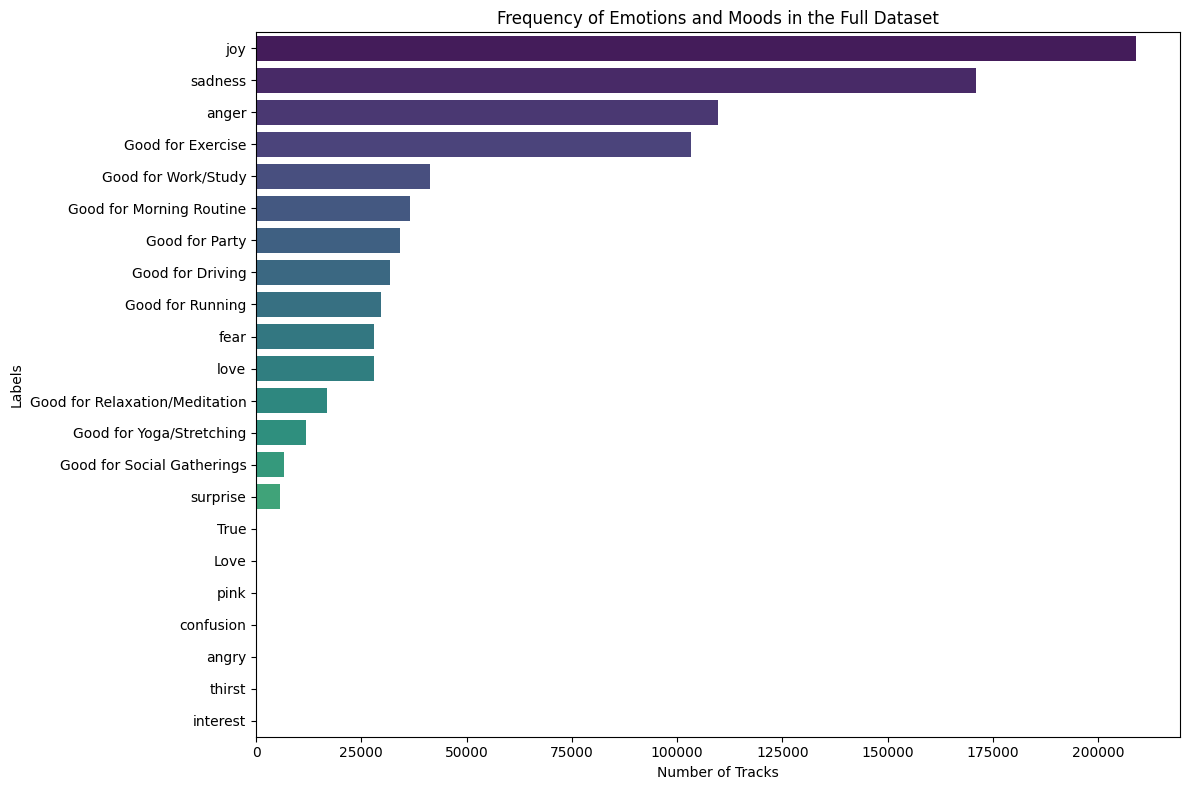

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# One hot encoding
df_emotions_encoded = pd.get_dummies(df['emotion'], prefix='', prefix_sep='').astype(int)

emotion_labels = list(df_emotions_encoded.columns)

activity_labels = [
    'Good for Party', 'Good for Work/Study', 'Good for Relaxation/Meditation',
    'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching',
    'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine'
]

df_extended = pd.concat([df, df_emotions_encoded], axis=1)

all_labels = emotion_labels + activity_labels

print(f"Total number of labels : {len(all_labels)}")

label_counts = df_extended[all_labels].sum().sort_values(ascending=False)
label_percentages = (df_extended[all_labels].sum() / len(df_extended) * 100).sort_values(ascending=False)

distribution_df = pd.DataFrame({'Number of Tracks': label_counts, 'Share (%)': label_percentages})
print(distribution_df)

plt.figure(figsize=(12, 8))
sns.barplot(
    x=label_counts.values,
    y=label_counts.index,
    hue=label_counts.index,
    palette='viridis',
    legend=False
)
plt.title('Frequency of Emotions and Moods in the Full Dataset')
plt.xlabel('Number of Tracks')
plt.ylabel('Labels')
plt.tight_layout()
plt.show()

# 3. Data cleaning
Remove very infrequent labels and merge the labels "anger" with "angry", and "love" with "Love".

In [21]:
emotion_mapping = {
    'Love': 'love',
    'angry': 'anger',
}

df['emotion'] = df['emotion'].replace(emotion_mapping)

df_emotions_encoded = pd.get_dummies(df['emotion'], prefix='', prefix_sep='').astype(int)

df_extended = pd.concat([df, df_emotions_encoded], axis=1)

emotion_labels = list(df_emotions_encoded.columns)
all_labels = emotion_labels + activity_labels
print(all_labels)

['True', 'anger', 'confusion', 'fear', 'interest', 'joy', 'love', 'pink', 'sadness', 'surprise', 'thirst', 'Good for Party', 'Good for Work/Study', 'Good for Relaxation/Meditation', 'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine']


In [22]:
CUTOFF_THRESHOLD = 50

label_sums = df_extended[all_labels].sum()

target_columns = label_sums[label_sums >= CUTOFF_THRESHOLD].index.tolist()

dropped_labels = sorted(set(all_labels) - set(target_columns))

print(f"Dropped labels ({len(dropped_labels)}): {dropped_labels}")
print(f"Remaining labels: {len(target_columns)}")

label_counts = df_extended[target_columns].sum().sort_values(ascending=False)
label_percentages = (label_counts / len(df_extended) * 100)

distribution_df = pd.DataFrame({
    'Number of Tracks': label_counts,
    'Share (%)': label_percentages
})

print(distribution_df)

Dropped labels (5): ['True', 'confusion', 'interest', 'pink', 'thirst']
Remaining labels: 15
                                Number of Tracks  Share (%)
joy                                       209009  37.902195
sadness                                   171078  31.023696
anger                                     109679  19.889454
Good for Exercise                         103304  18.733396
Good for Work/Study                        41320   7.493068
Good for Morning Routine                   36514   6.621537
Good for Party                             34084   6.180875
Good for Driving                           31872   5.779745
Good for Running                           29691   5.384237
fear                                       28097   5.095178
love                                       27966   5.071422
Good for Relaxation/Meditation             16969   3.077199
Good for Yoga/Stretching                   11847   2.148363
Good for Social Gatherings                  6757   1.225331
surpris

# 4. Get random sample to speed expreimental phase

In [26]:
SAMPLE_SIZE = 50000

df_sample = df_extended.sample(n=SAMPLE_SIZE, random_state=42).copy()

print(f"Sample shape: {df_sample.shape}")

sample_percentages = (df_sample[target_columns].sum() / len(df_sample) * 100)
print("\nPercentage of each label in the sample:")
print(sample_percentages.round(2).sort_values(ascending=False))

Sample shape: (50000, 50)

Percentage of each label in the sample:
joy                               37.58
sadness                           31.01
anger                             19.97
Good for Exercise                 18.76
Good for Work/Study                7.44
Good for Morning Routine           6.74
Good for Party                     6.24
Good for Driving                   5.77
Good for Running                   5.42
love                               5.21
fear                               5.15
Good for Relaxation/Meditation     3.08
Good for Yoga/Stretching           2.12
Good for Social Gatherings         1.20
surprise                           1.08
dtype: float64


In [27]:
import re


def get_lyrics_cleaned(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower().strip()
    
    text = re.sub(r'[a-z0-9]+/[a-z0-9]+', '', text)

    if text.startswith("lyrics "):
        text = text[len("lyrics "):].strip()
    if text.startswith("written by "):
        text = text[len("written by "):].strip()
        
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\(.*?\)', '', text)
    
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df_sample['cleaned_text'] = df_sample['text'].astype(str).apply(get_lyrics_cleaned)

print("Before cleaning:")
print(df_sample['text'].iloc[:5])
print("\nAfter cleaning:")
print(df_sample['cleaned_text'].iloc[:5])

Before cleaning:
420798    Lyrics/Music Yellen/Pokrass Why are grown up p...
447960    Sharing's good, sharing's fine    But no one w...
119751    [Intro] Let it go, let it go Can’t hold it bac...
83902     [Intro: Sav'O] (Madara) J'S, J'S  [Verse 1: Sa...
318397    [Produced by: THEMPeople]  [Intro: Sample] "Lo...
Name: text, dtype: str

After cleaning:
420798    why are grown up peoples faces wrinkled like a...
447960    sharings good sharings fine but no one wants t...
119751    let it go let it go cant hold it back anymore ...
83902     js js if your friend gets packed and you pack ...
318397    love you know what do you know about love what...
Name: cleaned_text, dtype: str


# 5. Train, val and test split

In [28]:
from sklearn.model_selection import train_test_split

X = df_sample.drop(columns=target_columns)
y = df_sample[target_columns]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train: {X_train.shape[0]} rows (80%)")
print(f"Val: {X_val.shape[0]} rows (10%)")
print(f"Test: {X_test.shape[0]} rows (10%)")

Train: 40000 rows (80%)
Val: 5000 rows (10%)
Test: 5000 rows (10%)


# 6. Baseline model - TF-IDF + Logistic Regression

The first model serves as a baseline for comparison with more advanced neural architectures.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report


In [30]:
# Build TF-IDF matrix on training lyrics
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train['cleaned_text'])
X_val_tfidf = tfidf.transform(X_val['cleaned_text'])
X_test_tfidf = tfidf.transform(X_test['cleaned_text'])

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")

TF-IDF matrix shape (train): (40000, 20000)


In [31]:
# Train One-vs-Rest Logistic Regression classifier
lr_clf = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42),
    n_jobs=-1
)

lr_clf.fit(X_train_tfidf, y_train)

y_val_pred_lr = lr_clf.predict(X_val_tfidf)

f1_micro_lr = f1_score(y_val, y_val_pred_lr, average='micro', zero_division=0)
f1_macro_lr = f1_score(y_val, y_val_pred_lr, average='macro', zero_division=0)

print(f"[LR baseline] Validation micro-F1 : {f1_micro_lr:.4f}")
print(f"[LR baseline] Validation macro-F1 : {f1_macro_lr:.4f}")
print()
print(classification_report(y_val, y_val_pred_lr, target_names=target_columns, zero_division=0))

[LR baseline] Validation micro-F1 : 0.3764
[LR baseline] Validation macro-F1 : 0.1357

                                precision    recall  f1-score   support

                         anger       0.72      0.28      0.40      1015
                          fear       0.44      0.01      0.03       293
                           joy       0.70      0.53      0.60      1838
                          love       0.86      0.05      0.09       264
                       sadness       0.73      0.43      0.54      1542
                      surprise       1.00      0.04      0.08        48
                Good for Party       1.00      0.05      0.10       311
           Good for Work/Study       1.00      0.01      0.01       382
Good for Relaxation/Meditation       0.00      0.00      0.00       163
             Good for Exercise       0.68      0.04      0.07       930
              Good for Running       1.00      0.02      0.04       270
      Good for Yoga/Stretching       0.00      0

# 7. BiLSTM

In [32]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

PAD_TOKEN, UNK_TOKEN = '<PAD>', '<UNK>'

def build_vocab(texts, max_vocab=30000, min_freq=2):
    counter = Counter(tok for text in texts for tok in text.split())
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, freq in counter.most_common(max_vocab):
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(X_train['cleaned_text'])
print(f"Vocabulary size (with special tokens): {len(vocab):,}")

NUM_LABELS = len(target_columns)
MAX_LEN = 100

class LyricsDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=MAX_LEN):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True).values.astype('float32')
        self.vocab = vocab
        self.max_len = max_len

    def encode(self, text):
        ids = [self.vocab.get(tok, self.vocab[UNK_TOKEN]) for tok in text.split()[:self.max_len]]
        ids += [self.vocab[PAD_TOKEN]] * (self.max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):  return len(self.texts)
    def __getitem__(self, i):
        return self.encode(self.texts[i]), torch.tensor(self.labels[i])

train_ds = LyricsDataset(X_train['cleaned_text'], y_train, vocab)
val_ds = LyricsDataset(X_val['cleaned_text'], y_val, vocab)
test_ds = LyricsDataset(X_test['cleaned_text'], y_test, vocab)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Batches - train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Vocabulary size (with special tokens): 30,002
Batches - train: 625 | val: 79 | test: 79


In [33]:
class LyricsLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 num_layers=2, num_labels=NUM_LABELS, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (h, _) = self.lstm(emb)
        feat = torch.cat([h[-2], h[-1]], dim=1)
        return self.classifier(self.dropout(feat))

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

lstm_model = LyricsLSTM(vocab_size=len(vocab)).to(DEVICE)
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

Using device: cpu
LyricsLSTM(
  (embedding): Embedding(30002, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=15, bias=True)
)

Trainable parameters: 6,215,439


In [ ]:
import numpy as np
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

label_counts = y_train.sum(axis=0).values
pos_weight = torch.tensor((len(y_train) - label_counts) / label_counts, dtype=torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

EPOCHS = 5 # CHWILOWO ZMNIEJSZONE
PATIENCE = 3
epochs_no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1_micro': []}
best_val_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    lstm_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = lstm_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    lstm_model.eval()
    val_loss = 0.0
    all_preds, all_labels_v = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = lstm_model(X_batch)
            val_loss += criterion(logits, y_batch).item()
            preds = (torch.sigmoid(logits) > 0.3).cpu().numpy()
            all_preds.append(preds)
            all_labels_v.append(y_batch.cpu().numpy())
    val_loss /= len(val_loader)
    all_preds = np.vstack(all_preds)
    all_labels_v = np.vstack(all_labels_v)
    val_f1 = f1_score(all_labels_v, all_preds, average='micro', zero_division=0)

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1_micro'].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        torch.save(lstm_model.state_dict(), 'best_lstm.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss: {train_loss:.4f} | "
          f"val_loss: {val_loss:.4f} | "
          f"val_micro-F1: {val_f1:.4f}")

print(f"\nBest validation micro-F1: {best_val_f1:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'], label='Val loss')
axes[0].set_title('Loss curves - BiLSTM')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()

axes[1].plot(history['val_f1_micro'], color='green', label='Val micro-F1')
axes[1].set_title('Validation micro-F1 - BiLSTM')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].legend()

plt.tight_layout()
plt.show()

# 9. Baseline Models Comparison

In [ ]:
lstm_model.load_state_dict(torch.load('best_lstm.pt', map_location=DEVICE))
lstm_model.eval()

all_preds_lstm, all_labels_test = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = lstm_model(X_batch.to(DEVICE))
        preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
        all_preds_lstm.append(preds)
        all_labels_test.append(y_batch.numpy())

all_preds_lstm = np.vstack(all_preds_lstm)
all_labels_test_arr = np.vstack(all_labels_test)

y_test_pred_lr = lr_clf.predict(X_test_tfidf)

results = {
    'Model': ['TF-IDF + Logistic Regression', 'BiLSTM'],
    'Test micro-F1': [
        f1_score(y_test, y_test_pred_lr, average='micro', zero_division=0),
        f1_score(all_labels_test_arr, all_preds_lstm, average='micro', zero_division=0)
    ],
    'Test macro-F1': [
        f1_score(y_test, y_test_pred_lr, average='macro', zero_division=0),
        f1_score(all_labels_test_arr, all_preds_lstm, average='macro', zero_division=0)
    ]
}

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

results_df.plot(kind='bar', figsize=(8, 4), ylim=(0, 1), rot=0,
                color=['steelblue', 'coral'], edgecolor='black')
plt.title('Baseline Models - Test Set Comparison')
plt.ylabel('F1 Score')
plt.tight_layout()
plt.show()